# 03F: t-SNE + K-Means Clustering

## Objective
Use t-SNE to learn a 2D manifold embedding, then run K-Means on the embedding for style-based stock clustering.

## Note
t-SNE preserves local neighborhoods better than global geometry. Interpret cluster distances qualitatively, not as exact Euclidean separation.

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import kagglehub

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.


In [2]:
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
RAW_CACHE = DATA_DIR / 'sp500_raw.csv'
FEATURE_CACHE = DATA_DIR / 'clustering_features_latest.csv'

In [3]:
def create_clustering_features(stock_data: pd.DataFrame) -> pd.DataFrame:
    stock_data = stock_data.sort_values('date').reset_index(drop=True).copy()
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    stock_data['price_level'] = stock_data['close'] / 100
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    return stock_data

def load_raw_data() -> pd.DataFrame:
    if RAW_CACHE.exists():
        return pd.read_csv(RAW_CACHE)
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    df.to_csv(RAW_CACHE, index=False)
    return df

def load_feature_table(data: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE.exists():
        return pd.read_csv(FEATURE_CACHE)
    processed = pd.concat([create_clustering_features(data[data['Name'] == s]) for s in data['Name'].unique()], ignore_index=True)
    clustering_data = processed.sort_values('date').drop_duplicates('Name', keep='last').dropna().reset_index(drop=True)
    clustering_data.to_csv(FEATURE_CACHE, index=False)
    return clustering_data

data = load_raw_data()
clustering_data = load_feature_table(data)
feature_cols = ['volatility','avg_return','avg_volume','volume_volatility','momentum','price_range','trend_strength','price_level','volume_to_price_ratio']
X = clustering_data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(clustering_data[feature_cols].median(numeric_only=True))
X_scaled = StandardScaler().fit_transform(X)

print(f'Samples={len(clustering_data)}, Features={len(feature_cols)}')

Samples=505, Features=9


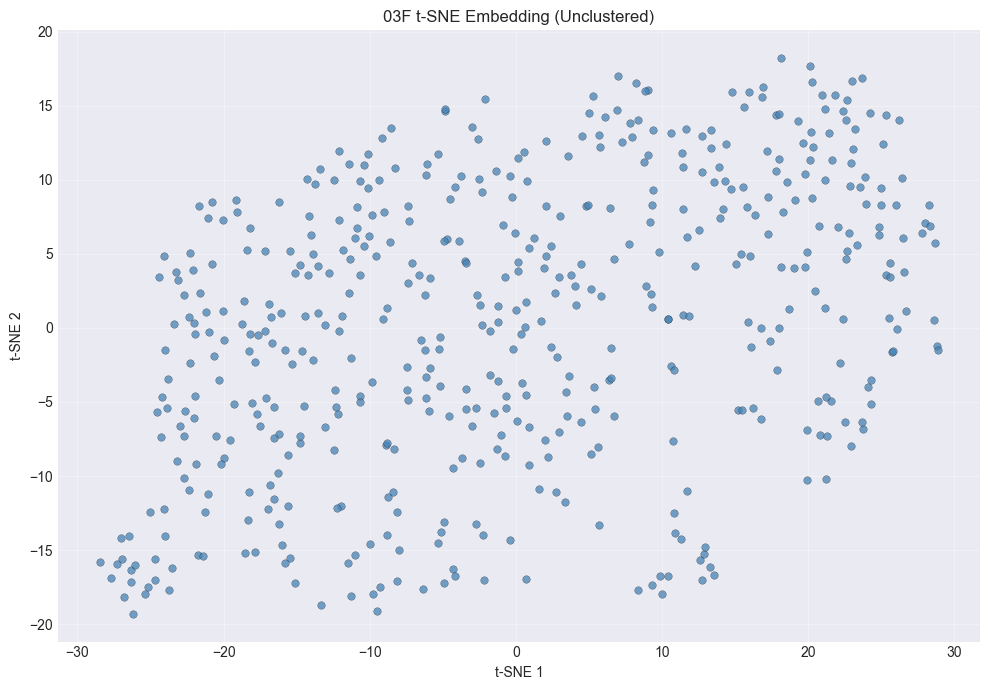

In [4]:
# Build 2D t-SNE embedding
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    max_iter=1200,
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], s=30, alpha=0.75, c='steelblue', edgecolor='black', linewidth=0.2)
ax.set_title('03F t-SNE Embedding (Unclustered)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR / '03F_01_tsne_embedding.png', dpi=300, bbox_inches='tight')
plt.show()

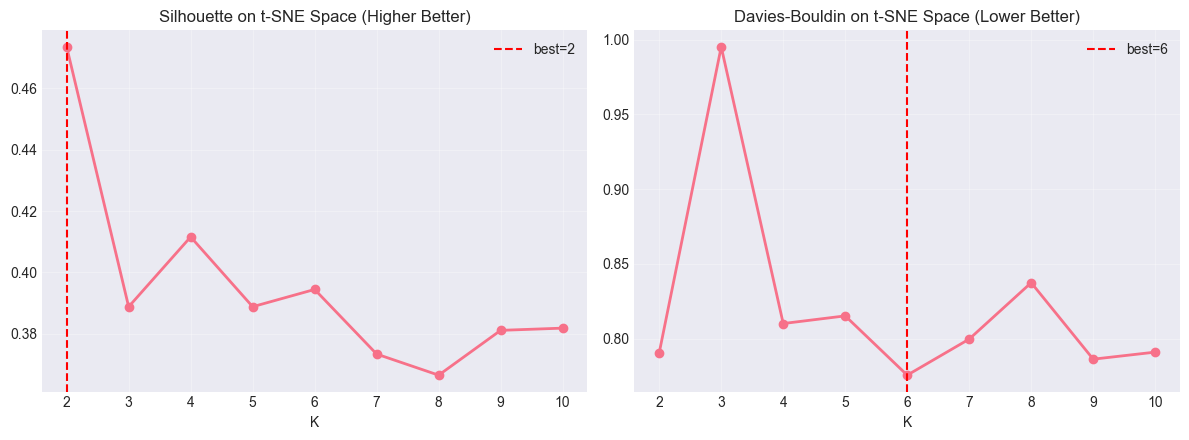

best_k_sil=2, best_k_db=6, chosen=2


In [5]:
# Select K on t-SNE manifold
k_values = range(2, 11)
sil_scores, db_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tsne)
    sil_scores.append(silhouette_score(X_tsne, labels))
    db_scores.append(davies_bouldin_score(X_tsne, labels))

best_k_sil = list(k_values)[int(np.argmax(sil_scores))]
best_k_db = list(k_values)[int(np.argmin(db_scores))]
optimal_k = best_k_sil

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_values), sil_scores, 'o-', linewidth=2)
axes[0].axvline(best_k_sil, color='red', linestyle='--', label=f'best={best_k_sil}')
axes[0].set_title('Silhouette on t-SNE Space (Higher Better)')
axes[0].set_xlabel('K')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(list(k_values), db_scores, 'o-', linewidth=2)
axes[1].axvline(best_k_db, color='red', linestyle='--', label=f'best={best_k_db}')
axes[1].set_title('Davies-Bouldin on t-SNE Space (Lower Better)')
axes[1].set_xlabel('K')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(GRAPH_DIR / '03F_02_k_selection_tsne_space.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'best_k_sil={best_k_sil}, best_k_db={best_k_db}, chosen={optimal_k}')

In [6]:
# Final clustering on t-SNE coordinates
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clustering_data['cluster'] = kmeans_final.fit_predict(X_tsne)

sil = silhouette_score(X_tsne, clustering_data['cluster'])
dbi = davies_bouldin_score(X_tsne, clustering_data['cluster'])

cluster_summary = clustering_data.groupby('cluster')[feature_cols].mean().round(4)
cluster_sizes = clustering_data['cluster'].value_counts().sort_index()

print(cluster_sizes)
print(f'Silhouette={sil:.4f}, Davies-Bouldin={dbi:.4f}')
display(cluster_summary)

cluster_summary.to_csv(DATA_DIR / '03F_cluster_feature_summary.csv')
clustering_data[['Name', 'cluster'] + feature_cols].to_csv(DATA_DIR / '03F_stock_cluster_assignments.csv', index=False)

cluster
0    235
1    270
Name: count, dtype: int64
Silhouette=0.4736, Davies-Bouldin=0.7905


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0196,0.0008,7.033487e+06,0.4100,0.0140,0.0319,0.3915,1.2439,323152.9236
1,0.0170,-0.0036,3.301061e+06,0.4082,-0.0706,0.0290,0.1523,0.9329,78567.8447


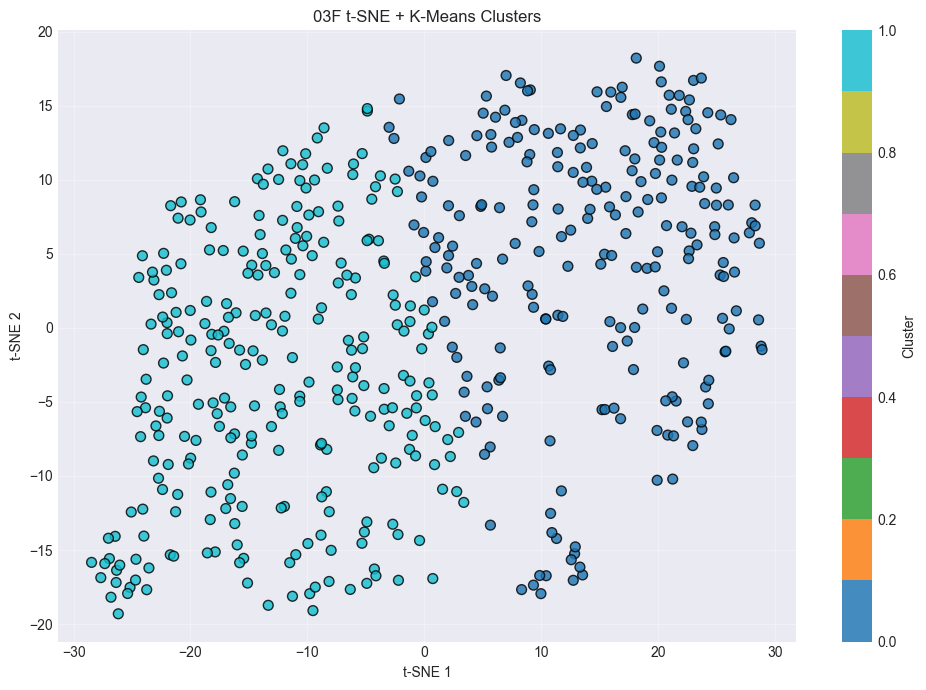

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clustering_data['cluster'], cmap='tab10', s=50, edgecolor='black', alpha=0.82)
ax.set_title('03F t-SNE + K-Means Clusters')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(alpha=0.3)
plt.colorbar(sc, label='Cluster')
plt.tight_layout()
plt.savefig(GRAPH_DIR / '03F_03_tsne_cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation and Financial Interpretation
Use this section to assess statistical quality and practical finance meaning of clusters.

- Statistical checks: cluster concentration, feature differentiation profile.
- Finance checks: return-risk tradeoff, momentum dispersion, and liquidity context.
- Portfolio use: identify aggressive, defensive, and balanced baskets by regime.

=== Cluster Composition ===


,count,weight_pct
cluster,,
0,235,46.53
1,270,53.47


=== Cluster Feature Profile (mean) ===


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0196,0.0008,7.033487e+06,0.4100,0.0140,0.0319,0.3915,1.2439,323152.9236
1,0.0170,-0.0036,3.301061e+06,0.4082,-0.0706,0.0290,0.1523,0.9329,78567.8447


=== Risk-Return Lens ===


,avg_return,volatility,momentum,price_range,return_to_risk
cluster,,,,,
0,0.0008,0.0196,0.0140,0.0319,0.0423
1,-0.0036,0.0170,-0.0706,0.0290,-0.2085


[Insight] Cluster 0 has the strongest return-to-risk proxy in this snapshot.
[Insight] Cluster 1 is the most defensive regime by realized volatility.


C:\Users\25012923g\AppData\Local\Temp\ipykernel_15120\1908501409.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')


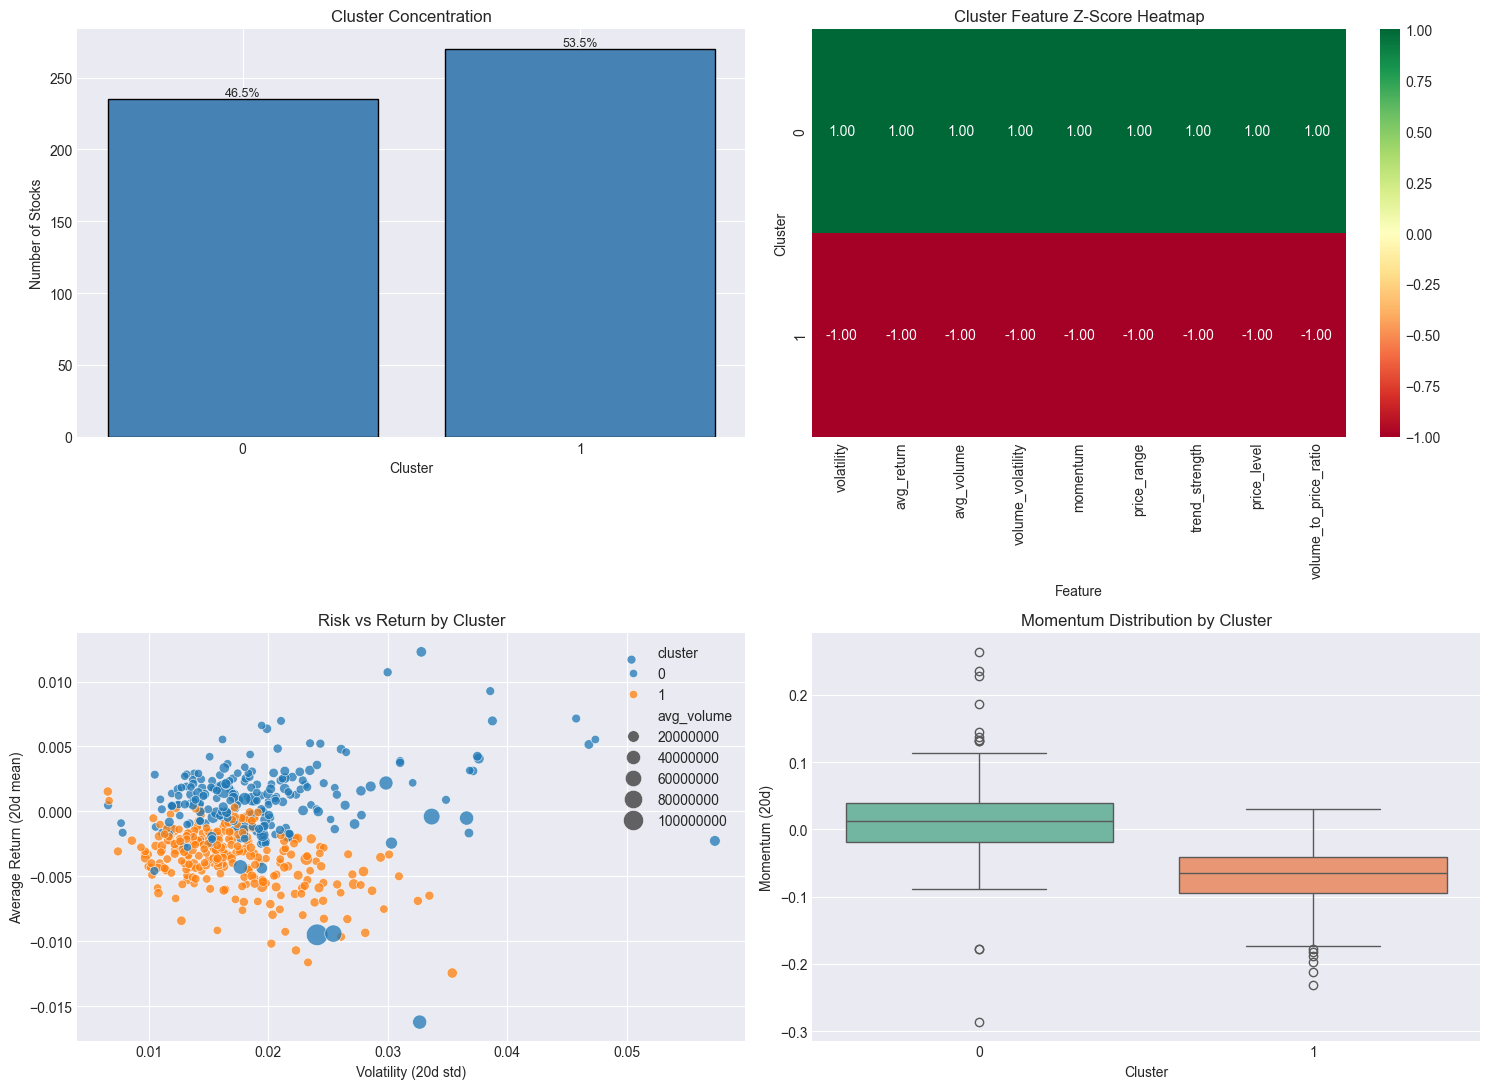

Saved evaluation dashboard: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph\03F_04_evaluation_dashboard.png


In [8]:
method_tag = '03F'
cluster_col = 'cluster'
eval_df = clustering_data.copy()

size_tbl = eval_df[cluster_col].value_counts().sort_index().rename('count').to_frame()
size_tbl['weight_pct'] = 100 * size_tbl['count'] / size_tbl['count'].sum()

profile_mean = eval_df.groupby(cluster_col)[feature_cols].mean()
profile_std = profile_mean.std(ddof=0).replace(0, np.nan)
profile_z = ((profile_mean - profile_mean.mean()) / profile_std).fillna(0.0)

risk_cols = ['avg_return', 'volatility', 'momentum', 'price_range']
risk_view = profile_mean[risk_cols].copy()
risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)

print('=== Cluster Composition ===')
display(size_tbl.round(2))

print('=== Cluster Feature Profile (mean) ===')
display(profile_mean.round(4))

print('=== Risk-Return Lens ===')
display(risk_view.round(4))

if len(risk_view) >= 2:
    best_rr = risk_view['return_to_risk'].idxmax()
    defensive = risk_view['volatility'].idxmin()
    print(f'[Insight] Cluster {best_rr} has the strongest return-to-risk proxy in this snapshot.')
    print(f'[Insight] Cluster {defensive} is the most defensive regime by realized volatility.')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

bars = axes[0, 0].bar(size_tbl.index.astype(str), size_tbl['count'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Cluster Concentration')
axes[0, 0].set_xlabel('Cluster'); axes[0, 0].set_ylabel('Number of Stocks')
for i, b in enumerate(bars):
    pct = size_tbl['weight_pct'].iloc[i]
    axes[0, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(profile_z, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Feature Z-Score Heatmap')
axes[0, 1].set_xlabel('Feature'); axes[0, 1].set_ylabel('Cluster')

sns.scatterplot(data=eval_df, x='volatility', y='avg_return', hue=cluster_col, size='avg_volume', sizes=(35, 240),
                alpha=0.75, palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Risk vs Return by Cluster')
axes[1, 0].set_xlabel('Volatility (20d std)'); axes[1, 0].set_ylabel('Average Return (20d mean)')

sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Momentum Distribution by Cluster')
axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('Momentum (20d)')

plt.tight_layout()
dashboard_path = GRAPH_DIR / f'{method_tag}_04_evaluation_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved evaluation dashboard: {dashboard_path}')